In [1]:
import os
import cv2
import glob as gb
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import plotly.express as px
import kagglehub


import warnings
warnings.filterwarnings("ignore")


from sklearn.model_selection import train_test_split
# Tensorflow
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Dropout,GlobalAveragePooling2D , BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import normalize

# metrics
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
import sys
import tensorflow as tf

print(f"Python Version: {sys.version}")
print(f"TensorFlow Version: {tf.__version__}")

Python Version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow Version: 2.19.0


In [ ]:

# Download latest version
path = kagglehub.dataset_download("yusufemir/lemon-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/yusufemir/lemon-quality-dataset/versions/1


In [ ]:
import os
import shutil
import glob
from sklearn.model_selection import train_test_split

# Ruta base del dataset descargado
ruta_original = os.path.join(path, "lemon_dataset")
ruta_dividida = "/content/dataset_dividido"
os.makedirs(ruta_dividida, exist_ok=True)

# Iterar por clase
for clase in os.listdir(ruta_original):
    ruta_clase = os.path.join(ruta_original, clase)
    imagenes = glob.glob(os.path.join(ruta_clase, "*.*"))

    print(f"📂 {clase} → {len(imagenes)} imágenes")

    if len(imagenes) < 2:
        print(f"⚠️ Clase '{clase}' omitida por tener pocas imágenes")
        continue

    # Dividir 80% train, 10% val, 10% test
    img_train, img_temp = train_test_split(imagenes, test_size=0.2, stratify=[clase]*len(imagenes), random_state=42)
    img_val, img_test = train_test_split(img_temp, test_size=0.5, stratify=[clase]*len(img_temp), random_state=42)

    def mover(imgs, split):
        dest = os.path.join(ruta_dividida, split, clase)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            shutil.copy(img, dest)

    mover(img_train, 'train')
    mover(img_val, 'val')
    mover(img_test, 'test')


📂 good_quality → 1125 imágenes
📂 .git → 0 imágenes
⚠️ Clase '.git' omitida por tener pocas imágenes
📂 empty_background → 452 imágenes
📂 bad_quality → 951 imágenes


In [ ]:
import shutil
import os

carpetas = ['train', 'val', 'test']
for subset in carpetas:
    ruta = f'/content/dataset_dividido/{subset}/empty_background'
    if os.path.exists(ruta):
        shutil.rmtree(ruta)
        print(f"🗑️ Eliminada clase 'empty_background' de {subset}")


🗑️ Eliminada clase 'empty_background' de train
🗑️ Eliminada clase 'empty_background' de val
🗑️ Eliminada clase 'empty_background' de test


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Inicializar generador con rescale
datagen = ImageDataGenerator(rescale=1./255)

# Parámetros
batch_size = 16
num_classes=1
target_size = (96, 96)

# Generadores corregidos para clasificación binaria, con color_mode='grayscale'
train_generator = datagen.flow_from_directory(
    directory='/content/dataset_dividido/train',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    color_mode='grayscale'
)

val_generator = datagen.flow_from_directory(
    directory='/content/dataset_dividido/val',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    color_mode='grayscale'
)

test_generator = datagen.flow_from_directory(
    directory='/content/dataset_dividido/test',
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

Found 1988 images belonging to 2 classes.
Found 394 images belonging to 2 classes.
Found 394 images belonging to 2 classes.


In [ ]:
input_shape = (96, 96, 1)  # Update input shape for grayscale
num_classes = 1  # salida binaria

model = Sequential([
    Conv2D(128, (3, 3), strides=(1, 1), padding="same", activation="relu", input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(64, (3, 3), strides=(1, 1), activation="relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(32, (3, 3), strides=(1, 1), activation="relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(64, (3, 3), strides=(1, 1), activation="relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(32, (3, 3), strides=(1, 1), activation="relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(16 , activation="relu"),
    Dense(num_classes , activation="sigmoid")
])

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 96, 96, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 46, 46, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 21, 21, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 2, 2, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,553 (513.88 KB)

 Trainable params: 131,297 (512.88 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer , loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early = EarlyStopping(
    patience=12,
    restore_best_weights=True,
    monitor='val_loss'
)

# Guardar en formato nativo moderno (.keras)
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# Guardar en formato HDF5 clásico (.h5)
checkpoint_h5 = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)


In [ ]:
history = model.fit(
    train_generator,
    epochs=200,
    validation_data=val_generator,
    callbacks=[early, checkpoint]
)

Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.5723 - loss: 0.6669 - val_accuracy: 0.5533 - val_loss: 0.6708
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7784 - loss: 0.4605 - val_accuracy: 0.8401 - val_loss: 0.5721
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8517 - loss: 0.3377 - val_accuracy: 0.9036 - val_loss: 0.4094
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9096 - loss: 0.2348 - val_accuracy: 0.9467 - val_loss: 0.2468
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9148 - loss: 0.2309 - val_accuracy: 0.9467 - val_loss: 0.1566
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9297 - loss: 0.1867 - val_accuracy: 0.9492 - val_loss: 0.1310
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9176 - loss: 0.2097 - val_accuracy: 0.9492 - val_loss: 0.1267
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9393 - loss: 0.1773 -

In [ ]:
loss , accuracy = model.evaluate(test_generator)
print("Accuracy is === ",accuracy)
print("Loss is == ",loss)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0027
Accuracy is ===  1.0
Loss is ==  0.0031187443528324366


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


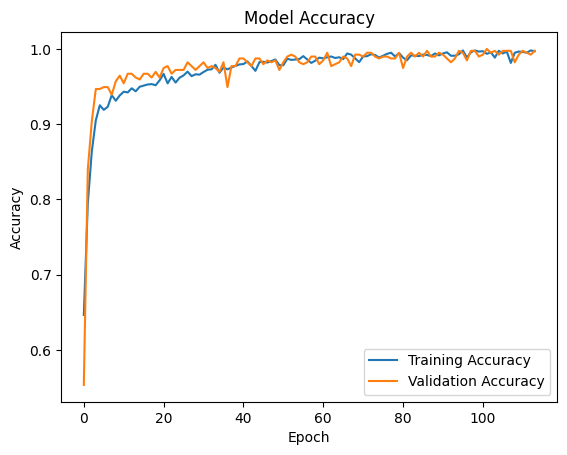

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

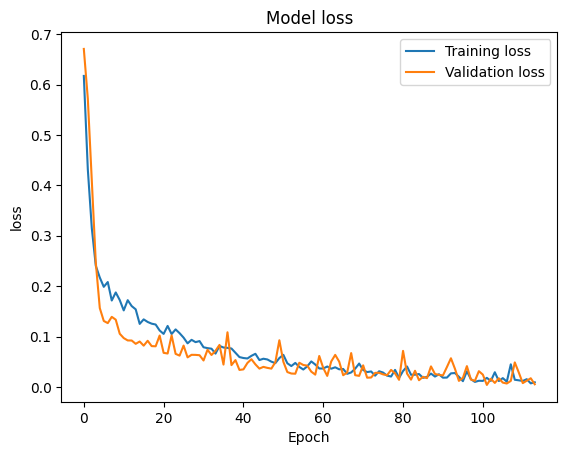

In [ ]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# Load the best model
best_model = load_model('best_model.keras')

# Get predictions from the test set
predictions = best_model.predict(test_generator)

# Get the actual labels from the test_generator
actual_labels = test_generator.classes

# Convert predictions to binary classes (0 or 1)
# Since the model uses a sigmoid activation for binary classification,
# we can use a threshold (e.g., 0.5) to convert probabilities to class labels.
predicted_labels = (predictions > 0.5).astype(int)

# Get the class labels from the generator
class_labels = list(test_generator.class_indices.keys())
print("Class Labels:", class_labels)

# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print("\nConfusion Matrix:")
print(conf_matrix)

# Calculate and print the classification report
class_report = classification_report(actual_labels, predicted_labels, target_names=class_labels)
print("\nClassification Report:")
print(class_report)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Class Labels: ['bad_quality', 'good_quality']

Confusion Matrix:
[[179   0]
 [  0 215]]

Classification Report:
              precision    recall  f1-score   support

 bad_quality       1.00      1.00      1.00       179
good_quality       1.00      1.00      1.00       215

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394



In [ ]:
loss1 , accuracy1 = best_model.evaluate(test_generator)
print("Accuracy is === ",accuracy1)
print("Loss is == ",loss1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.0027


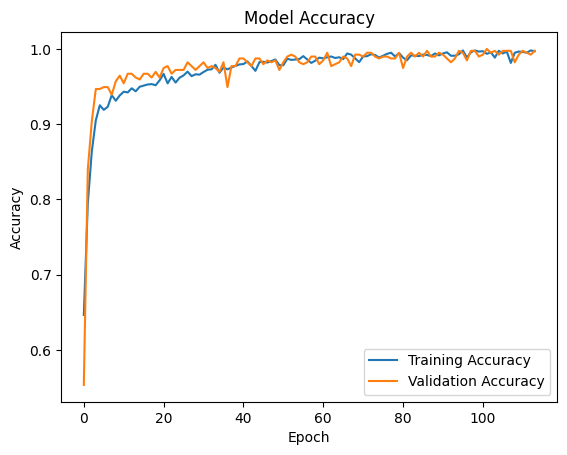

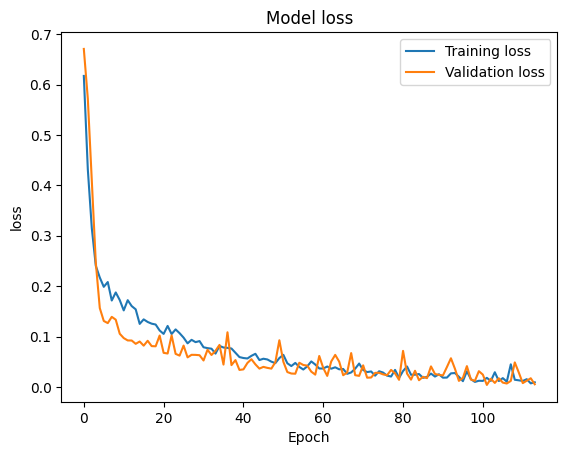

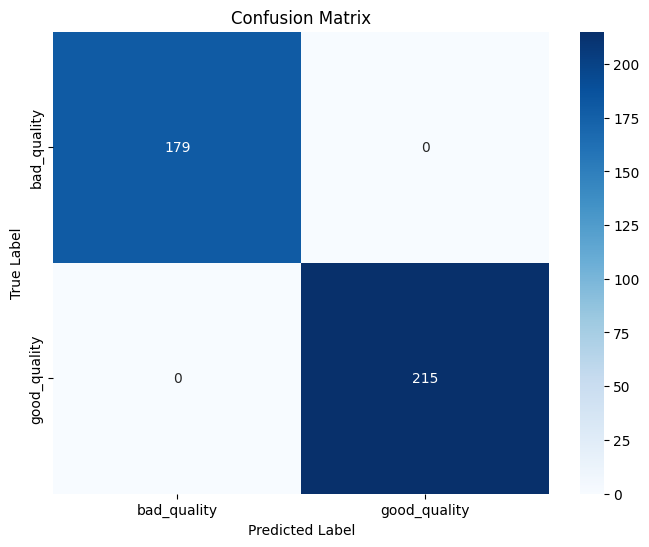

Saved model_accuracy_plot.png, model_loss_plot.png, and confusion_matrix_plot.png
The best model is saved as best_model.keras


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Save Accuracy Plot
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig('model_accuracy_plot.png')
plt.show()

# Save Loss Plot
plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.savefig('model_loss_plot.png')
plt.show()

# Save Confusion Matrix as image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('confusion_matrix_plot.png')
plt.show()


print("Saved model_accuracy_plot.png, model_loss_plot.png, and confusion_matrix_plot.png")
print("The best model is saved as best_model.keras")

In [3]:
import tensorflow as tf

print(f"Keras Version: {tf.keras.__version__}")

Keras Version: 3.10.0
